# LSTM for Stock Price Prediction

In [33]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [34]:
import os
import pandas as pd

csv_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)

print("Using dataset:", csv_path)

df = pd.read_csv(csv_path)
df.head()

Using dataset: /kaggle/input/datasets/iamtanmayshukla/apple-inc-aapl-stock-data-1980-2024/aapl_us_d.csv


,Date,Open,High,Low,Close,Volume
0,1984-09-07,0.100763,0.101999,0.099546,0.100763,9.767604e+07
1,1984-09-10,0.100763,0.101071,0.098340,0.100165,7.581254e+07
2,1984-09-11,0.101071,0.103814,0.101071,0.101999,1.787705e+08
3,1984-09-12,0.101999,0.102597,0.098928,0.098928,1.561713e+08
4,1984-09-13,0.104432,0.104730,0.104432,0.104432,2.432310e+08


In [35]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

data = df[['Close']].dropna().values   

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [36]:
def create_sequences(data, seq_length=60):
    X,y=[],[]
    for i in range(seq_length,len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X),np.array(y)

X,y=create_sequences(data_scaled,60)
print(X.shape, y.shape)

(10020, 60, 1) (10020, 1)


In [37]:

split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [38]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [39]:
# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm=nn.LSTM(1,64,batch_first=True)
        self.fc=nn.Linear(64,1)
    def forward(self,x):
        out,_=self.lstm(x)
        out=out[:,-1,:]
        return self.fc(out)

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
losses = []

for epoch in range(epochs):
    model.train()

    X_batch = X_train.to(device)
    y_batch = y_train.to(device)

    optimizer.zero_grad()
    outputs = model(X_batch)

    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch {epoch+1} | Loss: {loss.item():.6f}")

Epoch 1 | Loss: 0.001154
Epoch 2 | Loss: 0.000978
Epoch 3 | Loss: 0.001058
Epoch 4 | Loss: 0.001053
Epoch 5 | Loss: 0.000985
Epoch 6 | Loss: 0.000947
Epoch 7 | Loss: 0.000957
Epoch 8 | Loss: 0.000975
Epoch 9 | Loss: 0.000967
Epoch 10 | Loss: 0.000936
Epoch 11 | Loss: 0.000908
Epoch 12 | Loss: 0.000899
Epoch 13 | Loss: 0.000904
Epoch 14 | Loss: 0.000905
Epoch 15 | Loss: 0.000892
Epoch 16 | Loss: 0.000870
Epoch 17 | Loss: 0.000853
Epoch 18 | Loss: 0.000846
Epoch 19 | Loss: 0.000844
Epoch 20 | Loss: 0.000838
Epoch 21 | Loss: 0.000823
Epoch 22 | Loss: 0.000806
Epoch 23 | Loss: 0.000792
Epoch 24 | Loss: 0.000785
Epoch 25 | Loss: 0.000779
Epoch 26 | Loss: 0.000766
Epoch 27 | Loss: 0.000749
Epoch 28 | Loss: 0.000734
Epoch 29 | Loss: 0.000723
Epoch 30 | Loss: 0.000712
Epoch 31 | Loss: 0.000697
Epoch 32 | Loss: 0.000678
Epoch 33 | Loss: 0.000662
Epoch 34 | Loss: 0.000648
Epoch 35 | Loss: 0.000631
Epoch 36 | Loss: 0.000610
Epoch 37 | Loss: 0.000588
Epoch 38 | Loss: 0.000569
Epoch 39 | Loss: 0.00

In [41]:
model.eval()

with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()

y_test_np = y_test.numpy()

# inverse scale
preds = scaler.inverse_transform(preds)
y_test_np = scaler.inverse_transform(y_test_np)

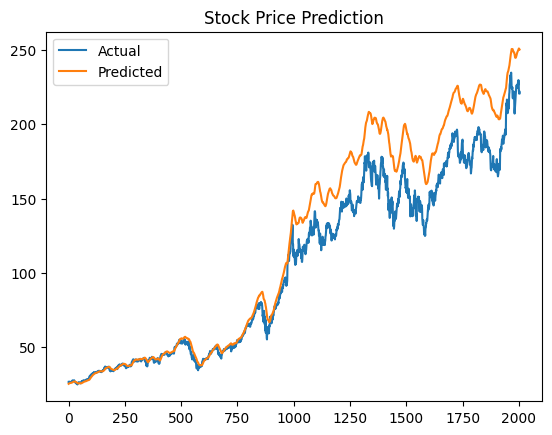

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_np, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

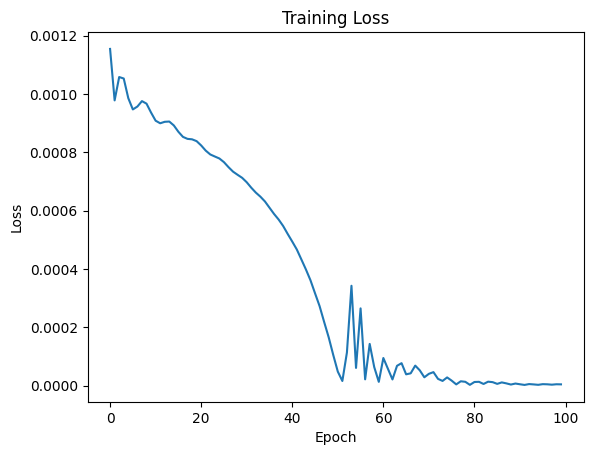

In [43]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()